In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv(r'C:\Users\zakir hussain\OneDrive\Desktop\Laptop-Price-Predictor-main\notebooks\pre_processed.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 112.1+ KB


## **EDA of Pre Processed Data**

### **Univariate Analysis:**
- plotting the distribution and frequency of each numerial column
- count ploting of each catagorial column

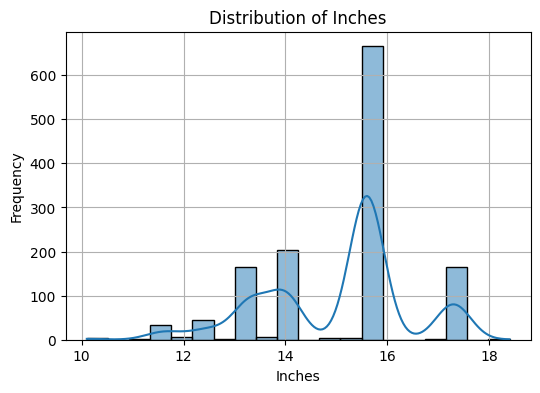

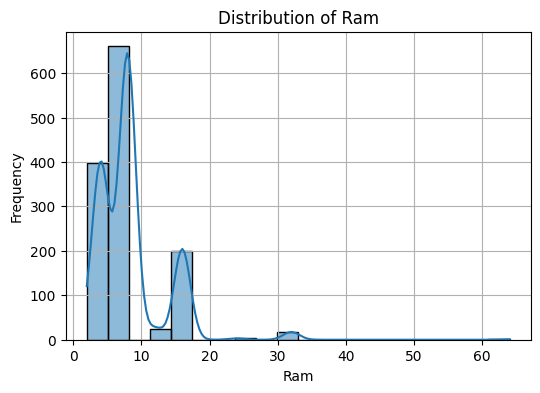

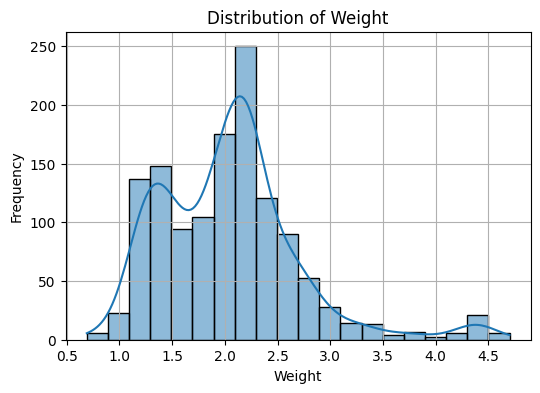

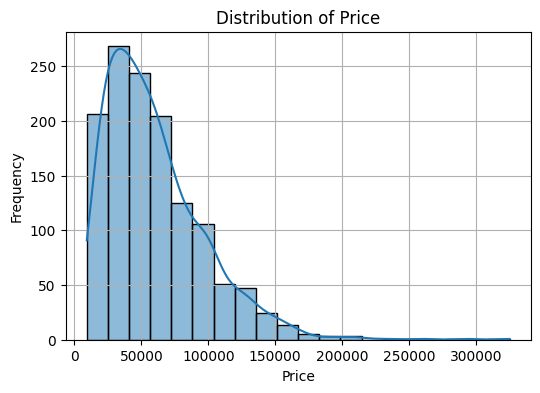

In [4]:
# Plotting the distribution of each numerical column
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

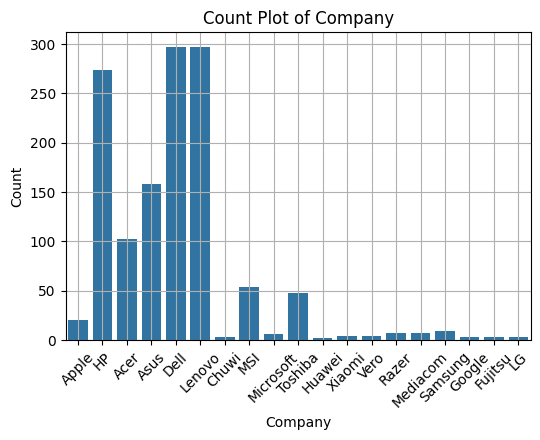

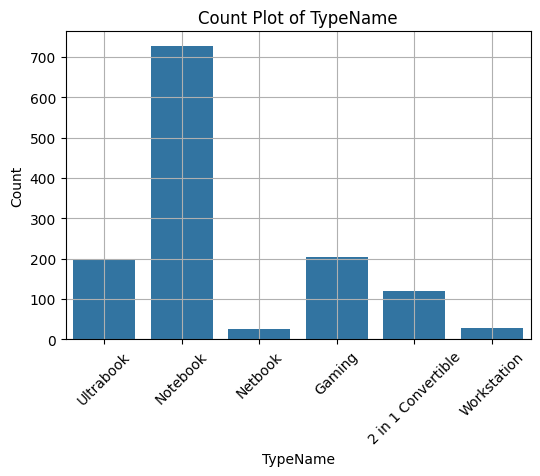

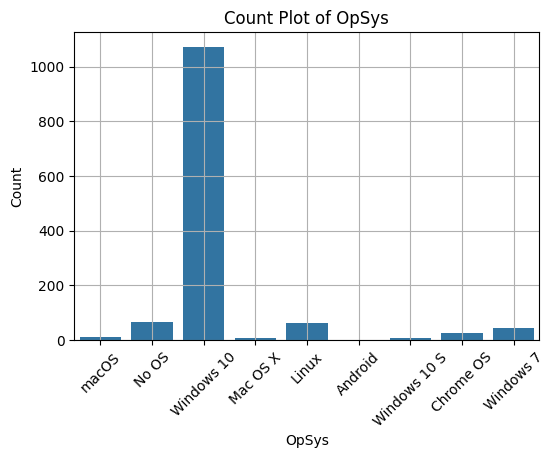

In [5]:
# Plotting count plots for categorical columns
categorical_cols = [col for col in df.select_dtypes(include=['object']).columns if df[col].nunique() < 20]

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

#### **Why these plots?**

- **Distribution plots** help in understanding the data's nature and distributional assumptions before applying statistical tests or modeling techniques.

- **Feature Engineering** Insights from **count plots** can guide feature engineering by identifying meaningful groupings or aggregations within categorical variables.

- **Data Quality Checks** Both types of plots are useful for detecting anomalies, checking data integrity, and validating assumptions about the dataset.

### **Insights**
- **Distribution and frequency/ Count** of different both Numerical and catagorial Features and Target label is observed.
- **price** column is important for us as it is our target label. It is found to be skewed, will reduce its skewness with log scale.

### **Bivariate Analysis:**
- plotting the numerial and catagorial features against the "Price", the target label to see the dependencies in the data.

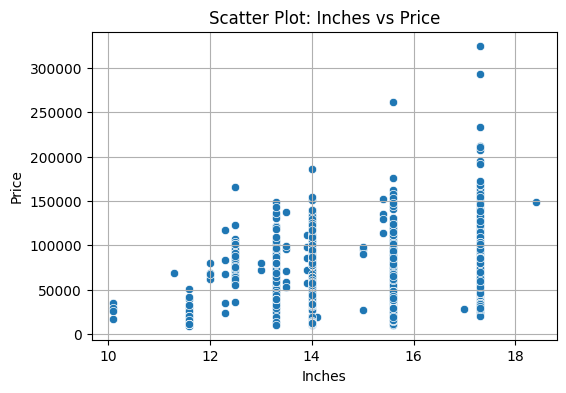

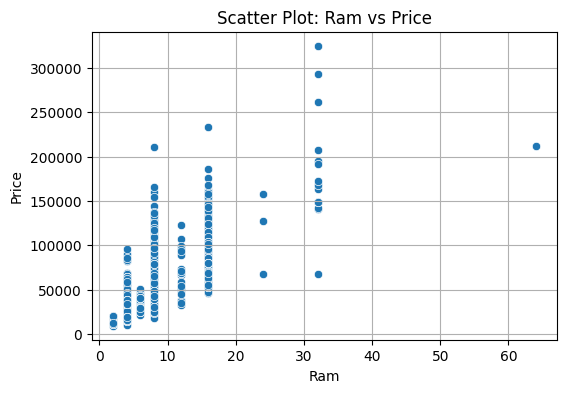

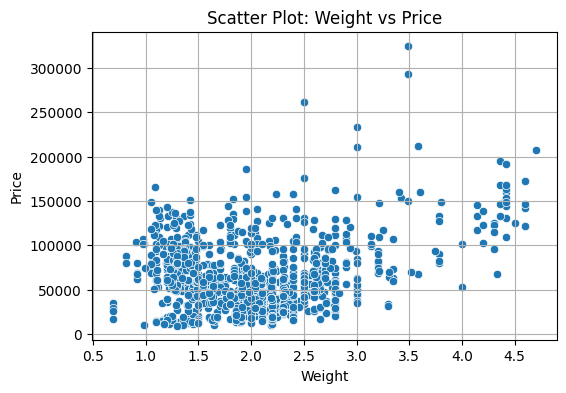

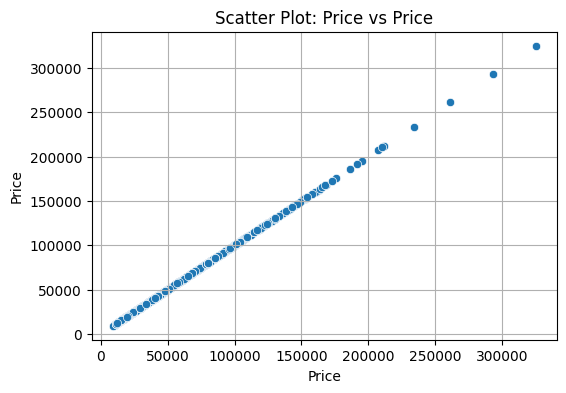

In [6]:
# Plotting scatter plots for numerical columns against 'Price'
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df['Price'])
    plt.title(f'Scatter Plot: {col} vs Price')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.grid(True)
    plt.show()

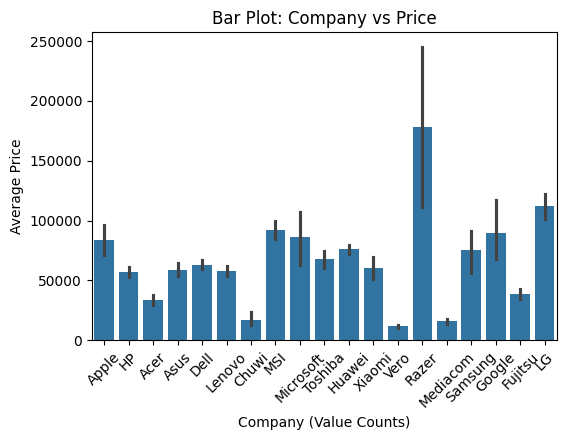

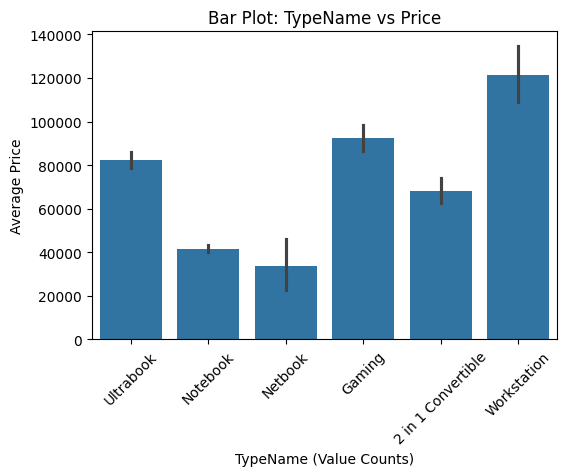

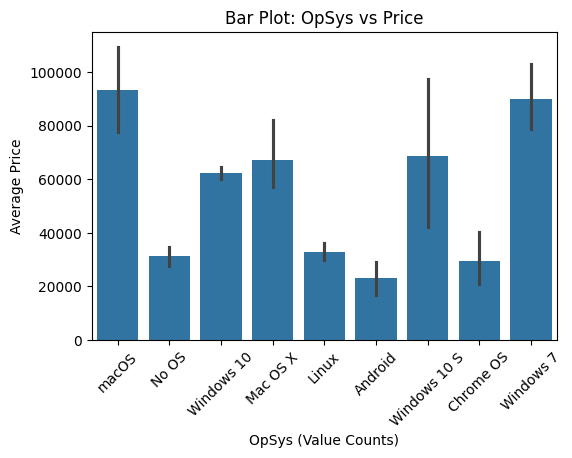

In [7]:
# Identifying categorical columns with less than 12 unique entries
categorical_cols = [col for col in df.select_dtypes(include=['object']).columns if df[col].nunique() < 20]

# Plotting bar plots for these categorical columns against 'Price'
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.barplot(x=col, y='Price', data=df)
    plt.title(f'Bar Plot: {col} vs Price')
    plt.xlabel(f'{col} (Value Counts)')
    plt.ylabel('Average Price')
    plt.xticks(rotation=45)

### **Insights:**
-

## **Visualizations of Processed Data**

### **Goals**
- similarly as above to reveal data trends in all the features
- including: either the created features are important and shows effect on price?
- New features: Touchscreen, IPS, PPI(Pixels per inch), Cpu brand,

In [8]:
new_features = ['PPI',]